# Task 3: Movie Review Sentiment Analysis

This version uses renamed variables, cleaner identifiers, and minor bug fixes while keeping the overall workflow and modelling approach intact. Run the notebook from top to bottom to generate fresh outputs.


In [1]:
# Core
import pandas as pd
import numpy as np

In [2]:
# Text Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud

In [4]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import nltk
# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

drive_root = '/content/drive/My Drive/'
expected_folder_name_part = 'AI' # Corrected based on available folders in My Drive

actual_ai_ml_folder = None
if os.path.exists(drive_root):
    for item in os.listdir(drive_root):
        # Find the folder that starts with the expected name part
        if item.startswith(expected_folder_name_part):
            actual_ai_ml_folder = item
            break

if actual_ai_ml_folder:
    # Now, construct the path to the dataset's parent folder
    # Assuming the '5. Movie Review Dataset' subfolder is correct
    base_path_for_data = os.path.join(drive_root, actual_ai_ml_folder, '5. Movie Review Dataset')

    print(f"Attempting to access data from: {base_path_for_data}")
    if os.path.exists(base_path_for_data):
        print(f"Listing contents of: {base_path_for_data}")
        print(os.listdir(base_path_for_data))

        # Load the dataframes
        movie_train_data = pd.read_csv(os.path.join(base_path_for_data, "train_movie_review.csv"))
        movie_validation_data = pd.read_csv(os.path.join(base_path_for_data, "val_movie_review.csv"))
        movie_test_data = pd.read_csv(os.path.join(base_path_for_data, "test_movie_review.csv"))

        print(movie_train_data.head())
        print(movie_train_data.info())
    else:
        print(f"The dataset subfolder '5. Movie Review Dataset' does not exist in '{os.path.join(drive_root, actual_ai_ml_folder)}'. Please check the subfolder name and casing.")
else:
    print(f"The main folder starting with '{expected_folder_name_part}' was not found in '{drive_root}'. Please check your Google Drive.")

Mounted at /content/drive
Attempting to access data from: /content/drive/My Drive/AI/5. Movie Review Dataset
Listing contents of: /content/drive/My Drive/AI/5. Movie Review Dataset
['5.Description Movie Review Dataset.txt', 'test_movie_review.csv', 'val_movie_review.csv', 'train_movie_review.csv']
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

drive_root = '/content/drive/My Drive/Ai/'
print(f"Listing contents of: {drive_root}")
if os.path.exists(drive_root):
    print(os.listdir(drive_root))
else:
    print(f"The directory '{drive_root}' does not exist. Please ensure Google Drive is mounted correctly.")

Listing contents of: /content/drive/My Drive/Ai/
The directory '/content/drive/My Drive/Ai/' does not exist. Please ensure Google Drive is mounted correctly.


In [ ]:
print("Train shape:", movie_train_data.shape)
print("Validation shape:", movie_validation_data.shape)
print("Test shape:", movie_test_data.shape)

print("\nTrain sentiment distribution:")
print(movie_train_data['sentiment'].value_counts())

print("\nValidation sentiment distribution:")
print(movie_validation_data['sentiment'].value_counts())

print("\nTest sentiment distribution:")
print(movie_test_data['sentiment'].value_counts())

Train shape: (35000, 3)
Validation shape: (5000, 3)
Test shape: (10000, 3)

Train sentiment distribution:
sentiment
0    17584
1    17416
Name: count, dtype: int64

Validation sentiment distribution:
sentiment
1    2545
0    2455
Name: count, dtype: int64

Test sentiment distribution:
sentiment
1    5039
0    4961
Name: count, dtype: int64


In [ ]:
for df in [movie_train_data, movie_validation_data, movie_test_data]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
print("Train missing values:")
print(movie_train_data.isnull().sum())

print("\nValidation missing values:")
print(movie_validation_data.isnull().sum())

print("\nTest missing values:")
print(movie_test_data.isnull().sum())

Train missing values:
review       0
sentiment    0
dtype: int64

Validation missing values:
review       0
sentiment    0
dtype: int64

Test missing values:
review       0
sentiment    0
dtype: int64


In [ ]:
movie_train_data = movie_train_data.dropna(subset=['review', 'sentiment'])
movie_validation_data = movie_validation_data.dropna(subset=['review', 'sentiment'])
movie_test_data = movie_test_data.dropna(subset=['review', 'sentiment'])

In [ ]:
movie_train_data['sentiment'] = movie_train_data['sentiment'].astype(int)
movie_validation_data['sentiment'] = movie_validation_data['sentiment'].astype(int)
movie_test_data['sentiment'] = movie_test_data['sentiment'].astype(int)

In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
english_stop_terms = set(stopwords.words('english'))
word_normalizer = WordNetLemmatizer()

def normalize_review_text(combined_review_text):
    combined_review_text = str(combined_review_text).lower()
    combined_review_text = re.sub(r'http\S+|www\S+', '', combined_review_text)
    combined_review_text = re.sub(r'<.*?>', '', combined_review_text)
    combined_review_text = combined_review_text.translate(str.maketrans('', '', string.punctuation))
    combined_review_text = re.sub(r'\d+', '', combined_review_text)

    words = combined_review_text.split()
    words = [word_normalizer.lemmatize(word) for word in words if word not in english_stop_terms]

    return " ".join(words)

In [27]:
movie_train_data['cleaned_review'] = movie_train_data['review'].apply(normalize_review_text)
movie_validation_data['cleaned_review'] = movie_validation_data['review'].apply(normalize_review_text)
movie_test_data['cleaned_review'] = movie_test_data['review'].apply(normalize_review_text)

movie_train_data[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0
3,A lot people get hung up on this films tag as ...,lot people get hung film tag childrens film ce...,1
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...,0


In [28]:
vocabulary_limit = 10000

review_tokenizer = Tokenizer(num_words=vocabulary_limit, oov_token="<OOV>")
review_tokenizer.fit_on_texts(movie_train_data['cleaned_review'])

In [29]:
train_token_sequences = review_tokenizer.texts_to_sequences(movie_train_data['cleaned_review'])
validation_token_sequences = review_tokenizer.texts_to_sequences(movie_validation_data['cleaned_review'])
test_token_sequences = review_tokenizer.texts_to_sequences(movie_test_data['cleaned_review'])

In [108]:
print(movie_train_data['cleaned_review'].iloc[0])
print(train_token_sequences[0][:20])

avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisation dance number heavily choreographed according extra dvd thrown away half body ever screen dance chorus north european appear small greek island set set number would disgraced cliff richards musical sixtiesmeryl see im actingstreep cant even make usual mugging effective overthetop musical grand piece winner take meryl met note director shot stillness camera gradually showing distance growing streep brosnan singing awful karaoke amateur night camera cannot stop moving like bad mtv one never settle enjoy music enthusiasm character even worse botched piece excre become highest grossing film uk best selling dvd boot blair campbell new labour really reduced uk zombie critical faculty anyone
[3957, 212, 2, 330, 2455, 171, 219, 1, 34, 398, 1

In [109]:
from wordcloud import WordCloud, STOPWORDS

cloud_exclusion_terms = set(STOPWORDS)

cloud_exclusion_terms.update([
    "one","get","got","go","make","really","still","even",
    "also","would","could","film","movie","movies"
])

In [110]:
combined_review_text = " ".join(movie_train_data['cleaned_review'])

In [111]:
review_word_cloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=cloud_exclusion_terms,
    colormap='viridis',   # try: plasma, cool, magma
    contour_color='black',
    contour_width=1
).generate(combined_review_text)

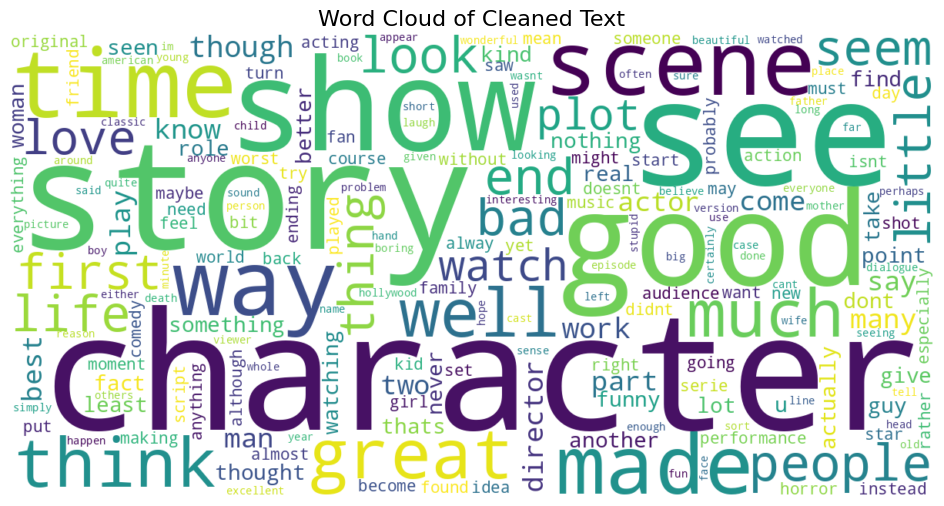

In [ ]:
plt.figure(figsize=(12,6))
plt.imshow(review_word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Text", fontsize=16)
plt.show()

In [ ]:
review_sequence_sizes = [len(seq) for seq in train_token_sequences]

review_padding_length = int(np.percentile(review_sequence_sizes, 95))

print("95th percentile sequence length:", review_padding_length)

95th percentile sequence length: 305


In [34]:
train_padded_reviews = pad_sequences(train_token_sequences, maxlen=review_padding_length, padding='post', truncating='post')
validation_padded_reviews = pad_sequences(validation_token_sequences, maxlen=review_padding_length, padding='post', truncating='post')
test_padded_reviews = pad_sequences(test_token_sequences, maxlen=review_padding_length, padding='post', truncating='post')

In [32]:
train_sentiment_labels = movie_train_data['sentiment'].values
validation_sentiment_labels = movie_validation_data['sentiment'].values
test_sentiment_labels = movie_test_data['sentiment'].values

In [35]:
print("train_padded_reviews shape:", train_padded_reviews.shape)
print("validation_padded_reviews shape:", validation_padded_reviews.shape)
print("test_padded_reviews shape:", test_padded_reviews.shape)

print("train_sentiment_labels shape:", train_sentiment_labels.shape)
print("validation_sentiment_labels shape:", validation_sentiment_labels.shape)
print("test_sentiment_labels shape:", test_sentiment_labels.shape)

train_padded_reviews shape: (35000, 305)
validation_padded_reviews shape: (5000, 305)
test_padded_reviews shape: (10000, 305)
train_sentiment_labels shape: (35000,)
validation_sentiment_labels shape: (5000,)
test_sentiment_labels shape: (10000,)


In [ ]:
#Model 1 Simple RNN (Baseline)
token_vocabulary_size = 10000
embedding_vector_size = 128

In [122]:
from tensorflow.keras.layers import Input # Added for explicit Input layer
baseline_recurrent_model = Sequential()

baseline_recurrent_model.add(Input(shape=(review_padding_length,))) # Added Input layer
baseline_recurrent_model.add(Embedding(
    input_dim=token_vocabulary_size,
    output_dim=embedding_vector_size
    # input_shape removed as it's now handled by the Input layer
))

baseline_recurrent_model.add(SimpleRNN(64))

baseline_recurrent_model.add(Dropout(0.5))

baseline_recurrent_model.add(Dense(1, activation='sigmoid'))

In [116]:
baseline_recurrent_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [105]:
baseline_recurrent_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 305, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,625 (3.86 MB)

 Trainable params: 1,010,625 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
baseline_stopper = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
baseline_training_history = baseline_recurrent_model.fit(
    train_padded_reviews,
    train_sentiment_labels,
    validation_data=(validation_padded_reviews, validation_sentiment_labels),
    epochs=10,
    batch_size=64,
    callbacks=[baseline_stopper]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4968 - loss: 0.6971 - val_accuracy: 0.5142 - val_loss: 0.6930
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5125 - loss: 0.6978 - val_accuracy: 0.4868 - val_loss: 0.6955
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5045 - loss: 0.6959 - val_accuracy: 0.4776 - val_loss: 0.6939
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5099 - loss: 0.6932 - val_accuracy: 0.4770 - val_loss: 0.6941


In [101]:
baseline_test_loss, baseline_test_accuracy = baseline_recurrent_model.evaluate(test_padded_reviews, test_sentiment_labels)

print("Simple RNN Test Loss:", baseline_test_loss)
print("Simple RNN Test Accuracy:", baseline_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5011 - loss: 0.6968
Simple RNN Test Loss: 0.6967561841011047
Simple RNN Test Accuracy: 0.5011000037193298


In [81]:
baseline_prediction_scores = baseline_recurrent_model.predict(test_padded_reviews)
baseline_predicted_classes = (baseline_prediction_scores > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


In [114]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test_sentiment_labels, baseline_predicted_classes, zero_division=0))

              precision    recall  f1-score   support

           0       0.45      0.02      0.04      4961
           1       0.50      0.97      0.66      5039

    accuracy                           0.50     10000
   macro avg       0.47      0.50      0.35     10000
weighted avg       0.47      0.50      0.36     10000



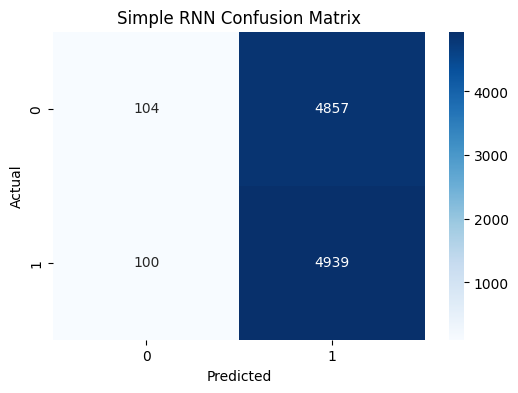

In [ ]:
baseline_confusion_table = confusion_matrix(test_sentiment_labels, baseline_predicted_classes)

plt.figure(figsize=(6,4))
sns.heatmap(baseline_confusion_table, annot=True, fmt='d', cmap='Blues')
plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

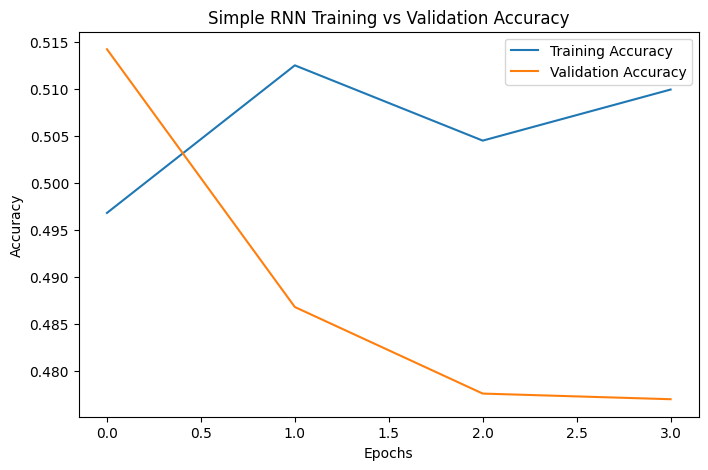

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(baseline_training_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_training_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Simple RNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

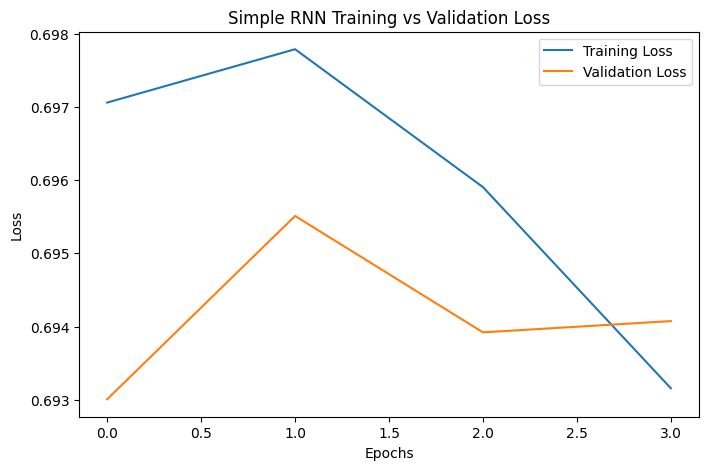

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(baseline_training_history.history['loss'], label='Training Loss')
plt.plot(baseline_training_history.history['val_loss'], label='Validation Loss')
plt.title("Simple RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [121]:
from tensorflow.keras.layers import Input # Added Input layer import
standard_lstm_model = Sequential()

standard_lstm_model.add(Input(shape=(review_padding_length,)))
standard_lstm_model.add(Embedding(
    input_dim=token_vocabulary_size,
    output_dim=128
))

standard_lstm_model.add(LSTM(64))

standard_lstm_model.add(Dropout(0.5))

standard_lstm_model.add(Dense(1, activation='sigmoid'))

In [19]:
standard_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
standard_lstm_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 305, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
standard_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [17]:
lstm_stopper = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
lstm_training_history = standard_lstm_model.fit(
    train_padded_reviews,
    train_sentiment_labels,
    validation_data=(validation_padded_reviews, validation_sentiment_labels),
    epochs=10,
    batch_size=64,
    callbacks=[lstm_stopper]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 298s 539ms/step - accuracy: 0.8365 - loss: 0.3744 - val_accuracy: 0.8664 - val_loss: 0.3256
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 292s 535ms/step - accuracy: 0.9067 - loss: 0.2416 - val_accuracy: 0.8706 - val_loss: 0.3326
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 306s 560ms/step - accuracy: 0.9299 - loss: 0.1865 - val_accuracy: 0.8754 - val_loss: 0.3146
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 305s 530ms/step - accuracy: 0.9437 - loss: 0.1506 - val_accuracy: 0.8746 - val_loss: 0.3497
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 291s 532ms/step - accuracy: 0.9571 - loss: 0.1210 - val_accuracy: 0.8696 - val_loss: 0.4086
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 289s 528ms/step - accuracy: 0.9647 - loss: 0.0986 - val_accuracy: 0.8692 - val_loss: 0.4623


In [120]:
from tensorflow.keras.layers import Input # Added Input layer import

standard_lstm_model = Sequential()

standard_lstm_model.add(Input(shape=(review_padding_length,))) # Explicitly define input shape
standard_lstm_model.add(Embedding(
    input_dim=token_vocabulary_size,
    output_dim=128,
    mask_zero=True
))

standard_lstm_model.add(LSTM(64))
standard_lstm_model.add(Dropout(0.5))
standard_lstm_model.add(Dense(1, activation='sigmoid'))

standard_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

standard_lstm_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 305, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_stopper = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lstm_training_history = standard_lstm_model.fit(
    train_padded_reviews,
    train_sentiment_labels,
    validation_data=(validation_padded_reviews, validation_sentiment_labels),
    epochs=10,
    batch_size=64,
    callbacks=[lstm_stopper]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8347 - loss: 0.3739 - val_accuracy: 0.8616 - val_loss: 0.3325
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9072 - loss: 0.2442 - val_accuracy: 0.8824 - val_loss: 0.2997
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9167 - loss: 0.2182 - val_accuracy: 0.8754 - val_loss: 0.3380
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9476 - loss: 0.1483 - val_accuracy: 0.8702 - val_loss: 0.3703
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9597 - loss: 0.1139 - val_accuracy: 0.8734 - val_loss: 0.4146


In [40]:
lstm_test_loss, lstm_test_accuracy = standard_lstm_model.evaluate(test_padded_reviews, test_sentiment_labels)
print("LSTM Accuracy:", lstm_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.5071 - loss: 0.6931
LSTM Accuracy: 0.507099986076355


In [41]:
lstm_prediction_scores = standard_lstm_model.predict(test_padded_reviews)
lstm_predicted_classes = (lstm_prediction_scores > 0.5).astype("int32")

lstm_confusion_table = confusion_matrix(test_sentiment_labels, lstm_predicted_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step


In [119]:
from tensorflow.keras.layers import Bidirectional, Input # Added Input layer import

token_vocabulary_size = 10000
review_padding_length = 305

bidirectional_lstm_model = Sequential()

bidirectional_lstm_model.add(Input(shape=(review_padding_length,))) # Explicitly define input shape
bidirectional_lstm_model.add(Embedding(
    input_dim=token_vocabulary_size,
    output_dim=128,
    mask_zero=True
))

bidirectional_lstm_model.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))

bidirectional_lstm_model.add(Dense(64, activation='relu'))
bidirectional_lstm_model.add(Dropout(0.5))

bidirectional_lstm_model.add(Dense(1, activation='sigmoid'))

bidirectional_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [47]:
bidirectional_stopper = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

bidirectional_training_history = bidirectional_lstm_model.fit(
    train_padded_reviews,
    train_sentiment_labels,
    validation_data=(validation_padded_reviews, validation_sentiment_labels),
    epochs=4,
    batch_size=128,
    callbacks=[bidirectional_stopper]
)

Epoch 1/4
274/274 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.8495 - loss: 0.3661 - val_accuracy: 0.8652 - val_loss: 0.3143
Epoch 2/4
274/274 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9029 - loss: 0.2562 - val_accuracy: 0.8696 - val_loss: 0.3036
Epoch 3/4
274/274 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.9233 - loss: 0.2061 - val_accuracy: 0.8640 - val_loss: 0.3210


In [48]:
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.4 MB/s eta 0:00:00


In [49]:
!pip install numpy==1.23.5
!pip install -q gensim --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 17.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [50]:
import gensim
print(gensim.__version__)


4.4.0


In [52]:
from gensim.models import Word2Vec

tokenized_review_sentences = movie_train_data['cleaned_review'].apply(lambda x: x.split()).tolist()

review_word2vec_model = Word2Vec(
    sentences=tokenized_review_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [54]:
embedding_vector_size = 100
review_word_index = review_tokenizer.word_index

word2vec_embedding_matrix = np.zeros((token_vocabulary_size, embedding_vector_size))

for word, i in review_word_index.items():
    if i < token_vocabulary_size and word in review_word2vec_model.wv:
        word2vec_embedding_matrix[i] = review_word2vec_model.wv[word]

In [55]:
word2vec_lstm_model = Sequential()

word2vec_lstm_model.add(Embedding(
    input_dim=token_vocabulary_size,
    output_dim=embedding_vector_size,
    weights=[word2vec_embedding_matrix],
    input_length=review_padding_length,
    trainable=False,
    mask_zero=True
))

word2vec_lstm_model.add(LSTM(64))
word2vec_lstm_model.add(Dropout(0.5))
word2vec_lstm_model.add(Dense(1, activation='sigmoid'))

word2vec_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

word2vec_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [56]:
word2vec_stopper = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

word2vec_training_history = word2vec_lstm_model.fit(
    train_padded_reviews,
    train_sentiment_labels,
    validation_data=(validation_padded_reviews, validation_sentiment_labels),
    epochs=10,
    batch_size=64,
    callbacks=[word2vec_stopper]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 198s 354ms/step - accuracy: 0.8237 - loss: 0.4011 - val_accuracy: 0.8596 - val_loss: 0.3267
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 191s 350ms/step - accuracy: 0.8628 - loss: 0.3323 - val_accuracy: 0.8790 - val_loss: 0.2924
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 194s 354ms/step - accuracy: 0.8775 - loss: 0.2979 - val_accuracy: 0.8776 - val_loss: 0.2854
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 193s 352ms/step - accuracy: 0.8846 - loss: 0.2847 - val_accuracy: 0.8832 - val_loss: 0.2863
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 191s 350ms/step - accuracy: 0.8927 - loss: 0.2665 - val_accuracy: 0.8792 - val_loss: 0.2866
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 192s 351ms/step - accuracy: 0.8975 - loss: 0.2575 - val_accuracy: 0.8874 - val_loss: 0.2720
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 191s 350ms/step - accuracy: 0.9019 - loss: 0.2456 - val_accuracy: 0.8894 - val_loss: 0.2858
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 202s 350ms/step - accuracy: 0.9053 -

In [58]:
word2vec_test_loss, word2vec_test_accuracy = word2vec_lstm_model.evaluate(test_padded_reviews, test_sentiment_labels)

print("Word2Vec LSTM Test Loss:", word2vec_test_loss)
print("Word2Vec LSTM Test Accuracy:", word2vec_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8868 - loss: 0.2718
Word2Vec LSTM Test Loss: 0.2717973291873932
Word2Vec LSTM Test Accuracy: 0.8867999911308289


In [59]:
word2vec_prediction_scores = word2vec_lstm_model.predict(test_padded_reviews)
word2vec_predicted_classes = (word2vec_prediction_scores > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step


In [64]:
print(classification_report(test_sentiment_labels, word2vec_predicted_classes, zero_division=0))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



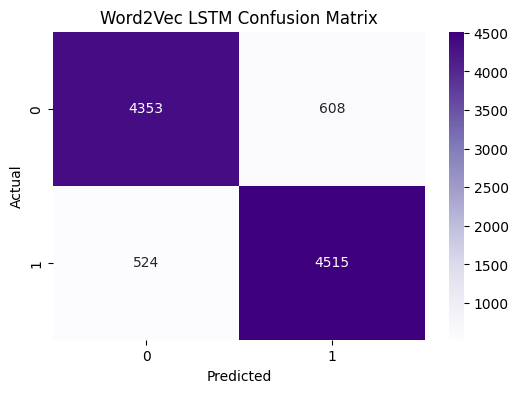

In [61]:
word2vec_confusion_table = confusion_matrix(test_sentiment_labels, word2vec_predicted_classes)

plt.figure(figsize=(6,4))
sns.heatmap(word2vec_confusion_table, annot=True, fmt='d', cmap='Purples')
plt.title("Word2Vec LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [84]:
#Comparison
accuracy_summary_table = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Accuracy": [baseline_test_accuracy, lstm_test_accuracy, word2vec_test_accuracy]
})

print(accuracy_summary_table)

           Model  Accuracy
0     Simple RNN    0.5011
1           LSTM    0.4851
2  Word2Vec LSTM    0.8868


In [85]:
baseline_test_loss, baseline_test_accuracy = baseline_recurrent_model.evaluate(test_padded_reviews, test_sentiment_labels)
print("Simple RNN Test Loss:", baseline_test_loss)
print("Simple RNN Test Accuracy:", baseline_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5011 - loss: 0.6968
Simple RNN Test Loss: 0.6967561841011047
Simple RNN Test Accuracy: 0.5011000037193298


In [67]:
lstm_test_loss, lstm_test_accuracy = standard_lstm_model.evaluate(test_padded_reviews, test_sentiment_labels)
print("LSTM Accuracy:", lstm_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.4851 - loss: 0.6934
LSTM Accuracy: 0.48510000109672546


In [68]:
word2vec_test_loss, word2vec_test_accuracy = word2vec_lstm_model.evaluate(test_padded_reviews, test_sentiment_labels)

print("Word2Vec LSTM Test Loss:", word2vec_test_loss)
print("Word2Vec LSTM Test Accuracy:", word2vec_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.8868 - loss: 0.2718
Word2Vec LSTM Test Loss: 0.2717973291873932
Word2Vec LSTM Test Accuracy: 0.8867999911308289


In [83]:
accuracy_summary_table = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Accuracy": [baseline_test_accuracy, lstm_test_accuracy, word2vec_test_accuracy]
})

print(accuracy_summary_table)

           Model  Accuracy
0     Simple RNN    0.5011
1           LSTM    0.4851
2  Word2Vec LSTM    0.8868


In [86]:
incorrect_prediction_ids = []

for i in range(len(test_sentiment_labels)):
    if test_sentiment_labels[i] != word2vec_predicted_classes[i]:
        incorrect_prediction_ids.append(i)

print("Total misclassified:", len(incorrect_prediction_ids))

Total misclassified: 1132


In [87]:
for i in incorrect_prediction_ids[:3]:
    print("Review:")
    print(movie_test_data['review'].iloc[i])
    print("Actual:", test_sentiment_labels[i])
    print("Predicted:", word2vec_predicted_classes[i])
    print("-"*80)

Review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers, and Yokozuna defe

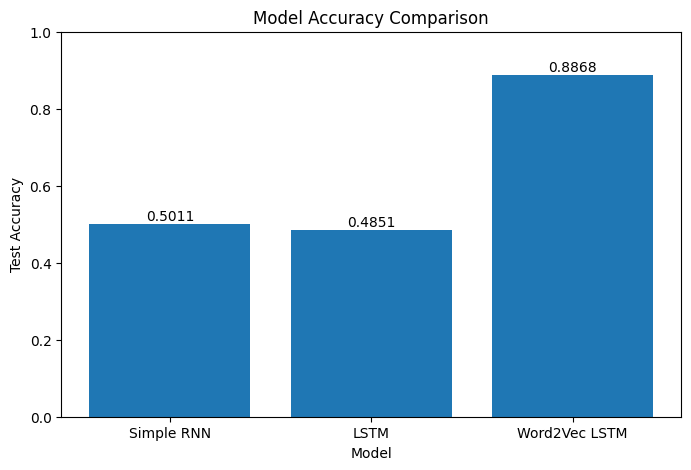

In [89]:
plt.figure(figsize=(8,5))
plt.bar(accuracy_summary_table["Model"], accuracy_summary_table["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for i, acc in enumerate(accuracy_summary_table["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center')

plt.show()

In [90]:
loss_summary_table = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Loss": [baseline_test_loss, lstm_test_loss, word2vec_test_loss]
})

print(loss_summary_table)

           Model      Loss
0     Simple RNN  0.696756
1           LSTM  0.693434
2  Word2Vec LSTM  0.271797


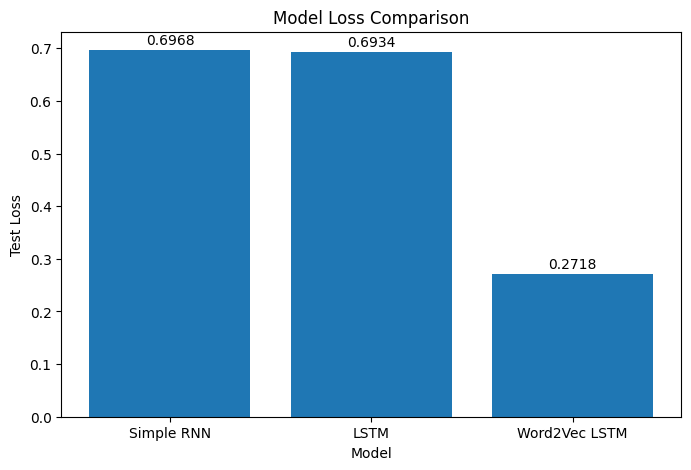

In [92]:
plt.figure(figsize=(8,5))
plt.bar(loss_summary_table["Model"], loss_summary_table["Loss"])
plt.title("Model Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Test Loss")

for i, loss in enumerate(loss_summary_table["Loss"]):
    plt.text(i, loss + 0.01, f"{loss:.4f}", ha='center')

plt.show()

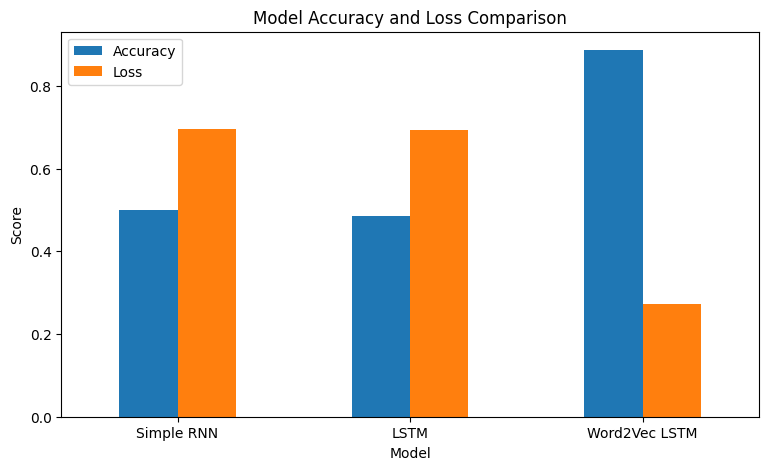

In [93]:
model_score_summary = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Accuracy": [baseline_test_accuracy, lstm_test_accuracy, word2vec_test_accuracy],
    "Loss": [baseline_test_loss, lstm_test_loss, word2vec_test_loss]
})

model_score_summary.plot(
    x="Model",
    y=["Accuracy", "Loss"],
    kind="bar",
    figsize=(9,5)
)

plt.title("Model Accuracy and Loss Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

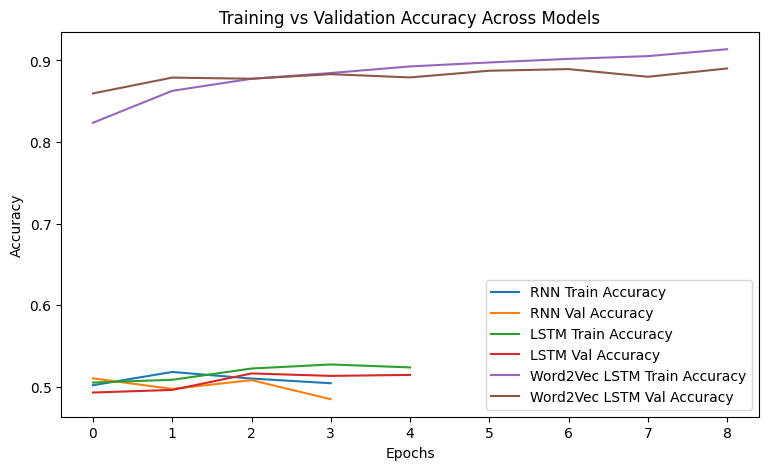

In [130]:
plt.figure(figsize=(9,5))

plt.plot(baseline_training_history.history['accuracy'], label='RNN Train Accuracy')
plt.plot(baseline_training_history.history['val_accuracy'], label='RNN Val Accuracy')

plt.plot(lstm_training_history.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(lstm_training_history.history['val_accuracy'], label='LSTM Val Accuracy')

plt.plot(word2vec_training_history.history['accuracy'], label='Word2Vec LSTM Train Accuracy')
plt.plot(word2vec_training_history.history['val_accuracy'], label='Word2Vec LSTM Val Accuracy')

plt.title("Training vs Validation Accuracy Across Models")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

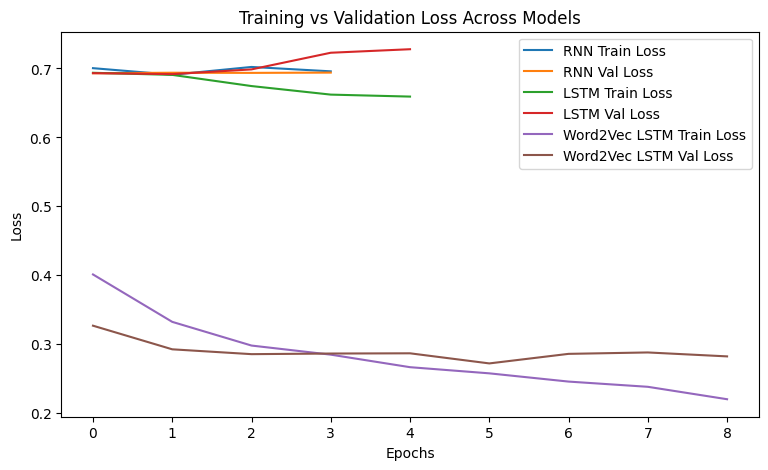

In [128]:
plt.figure(figsize=(9,5))

plt.plot(baseline_training_history.history['loss'], label='RNN Train Loss')
plt.plot(baseline_training_history.history['val_loss'], label='RNN Val Loss')

plt.plot(lstm_training_history.history['loss'], label='LSTM Train Loss')
plt.plot(lstm_training_history.history['val_loss'], label='LSTM Val Loss')

plt.plot(word2vec_training_history.history['loss'], label='Word2Vec LSTM Train Loss')
plt.plot(word2vec_training_history.history['val_loss'], label='Word2Vec LSTM Val Loss')

plt.title("Training vs Validation Loss Across Models")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [97]:
incorrect_prediction_ids = []

for i in range(len(test_sentiment_labels)):
    if test_sentiment_labels[i] != word2vec_predicted_classes[i]:
        incorrect_prediction_ids.append(i)

print("Total misclassified:", len(incorrect_prediction_ids))

Total misclassified: 1132


In [98]:
# Helper function for predicting a single custom review
def prepare_single_review(raw_review):
    cleaned_review = normalize_review_text(raw_review)
    review_sequence = review_tokenizer.texts_to_sequences([cleaned_review])
    padded_review = pad_sequences(
        review_sequence,
        maxlen=review_padding_length,
        padding='post',
        truncating='post'
    )
    return padded_review


In [99]:
sample_review_text = "This movie was bad and critical"

prepared_review_input = prepare_single_review(sample_review_text)
prediction_score = word2vec_lstm_model.predict(prepared_review_input)[0][0]

if prediction_score > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Negative


In [100]:
sample_review_text = "This movie was amazing and emotional"

prepared_review_input = prepare_single_review(sample_review_text)
prediction_score = word2vec_lstm_model.predict(prepared_review_input)[0][0]

if prediction_score > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Positive


In [132]:
import pickle

word2vec_lstm_model.save("sentiment_model.keras")

with open("review_tokenizer.pkl", "wb") as f:
    pickle.dump(review_tokenizer, f)

with open("review_padding_length.pkl", "wb") as f:
    pickle.dump(review_padding_length, f)

In [ ]:
!pip install -q streamlit

In [ ]:
code = r'''
import streamlit as st
import pickle
import re
import string
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

st.set_page_config(
    page_title="Movie Review Sentiment Classifier",
    layout="centered"
)

@st.cache_resource
def load_resources():
    model = load_model("sentiment_model.keras")

    with open("review_tokenizer.pkl", "rb") as f:
        tokenizer = pickle.load(f)

    with open("review_padding_length.pkl", "rb") as f:
        max_len = pickle.load(f)

    return model, tokenizer, max_len

model, tokenizer, max_len = load_resources()

def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def predict_review_sentiment(review_text):
    cleaned_text = clean_review_text(review_text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    prediction_score = model.predict(padded_sequence, verbose=0)[0][0]

    if prediction_score >= 0.5:
        sentiment = "Positive"
        confidence = prediction_score
    else:
        sentiment = "Negative"
        confidence = 1 - prediction_score

    return sentiment, confidence, cleaned_text

st.title("Movie Review Sentiment Classifier")

st.write(
    "Enter a movie review below. The trained LSTM model will classify the review as positive or negative."
)

review_input = st.text_area(
    "Movie Review",
    height=180,
    placeholder="Example: The movie was emotional, well acted, and worth watching."
)

if st.button("Predict Sentiment"):
    if review_input.strip() == "":
        st.warning("Please enter a review first.")
    else:
        sentiment, confidence, cleaned_text = predict_review_sentiment(review_input)

        st.subheader("Prediction Result")

        if sentiment == "Positive":
            st.success(f"Sentiment: {sentiment}")
        else:
            st.error(f"Sentiment: {sentiment}")

        st.write(f"Confidence: {confidence:.2%}")

        with st.expander("View cleaned review text"):
            st.write(cleaned_text)

st.markdown("---")
st.caption("Model used: LSTM sentiment classification model")
'''

with open("app.py", "w") as f:
    f.write(code)

print("app.py created successfully")

In [ ]:
!pkill -f streamlit

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.enableCORS false --server.enableXsrfProtection false & ./cloudflared tunnel --url http://localhost:8501